In [2]:
import polars as pl
import matplotlib.pyplot as plt

df = pl.read_parquet("../parquets/G_bitfinex_btcusd_trades.parquet")
df.null_count()

instrument,ingress_ts,transaction_ts,publish_ts,trade_id,price,qty,side,other_data
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,642


In [3]:
df = df.with_columns(
    pl.from_epoch("ingress_ts", time_unit="us"),
    pl.from_epoch("transaction_ts", time_unit="us"),
    pl.from_epoch("publish_ts", time_unit="us"),
)

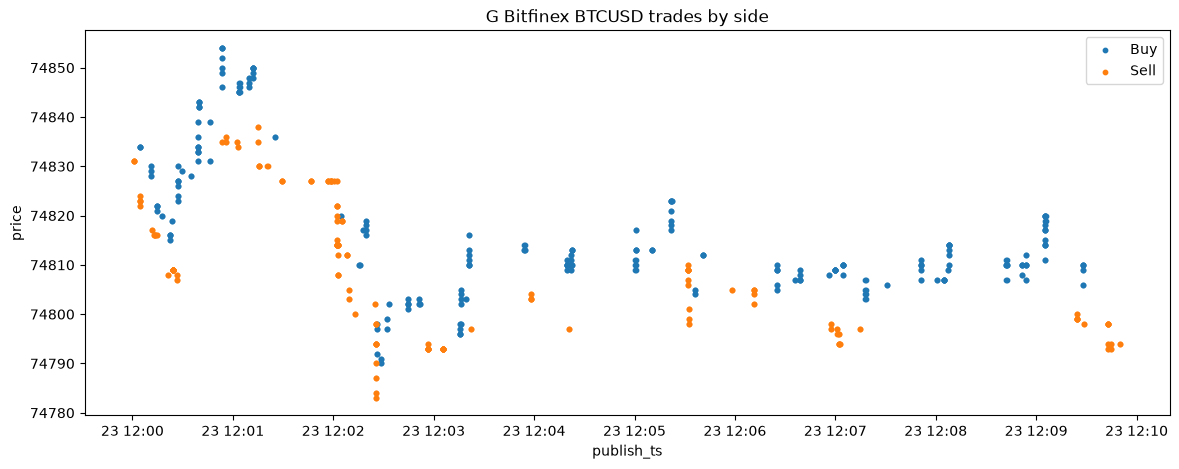

In [22]:
df_plot = df.sort("publish_ts")

plt.figure(figsize=(14, 5))

for side in df_plot["side"].unique().to_list():
    side_df = df_plot.filter(pl.col("side") == side)
    plt.scatter(side_df["publish_ts"], side_df["price"], s=10, label=side)

plt.title("G Bitfinex BTCUSD trades by side")
plt.xlabel("publish_ts")
plt.ylabel("price")
plt.legend()
plt.show()

In [23]:
df.select(
    pl.col("publish_ts").min().alias("min_publish_ts"),
    pl.col("publish_ts").max().alias("max_publish_ts"),
    pl.col("price").min().alias("min_price"),
    pl.col("price").max().alias("max_price"),
)

min_publish_ts,max_publish_ts,min_price,max_price
datetime[μs],datetime[μs],f64,f64
2026-05-23 12:00:00.914,2026-05-23 12:09:50.257,74783.0,74854.0


In [24]:
df_latency = df.with_columns(
    capture_latency_us=(pl.col("ingress_ts") - pl.col("publish_ts")).dt.total_microseconds()
)

df_latency.select(
    pl.col("capture_latency_us").min().alias("min_us"),
    pl.col("capture_latency_us").quantile(0.5).alias("p50_us"),
    pl.col("capture_latency_us").quantile(0.95).alias("p95_us"),
    pl.col("capture_latency_us").quantile(0.99).alias("p99_us"),
    pl.col("capture_latency_us").max().alias("max_us"),
)

min_us,p50_us,p95_us,p99_us,max_us
i64,f64,f64,f64,i64
15474,16690.0,20194.0,30912.0,43364


In [25]:
df.height - df.unique().height

0

In [26]:
df.select(
    pl.len().alias("rows"),
    pl.col("trade_id").n_unique().alias("unique_trade_ids"),
)

rows,unique_trade_ids
u32,u32
642,321


In [27]:
df.filter(pl.col("trade_id") == df.group_by("trade_id").len().filter(pl.col("len") > 1)["trade_id"][0]).sort("publish_ts")

instrument,ingress_ts,transaction_ts,publish_ts,trade_id,price,qty,side,other_data,duplicate_trade_event
str,datetime[μs],datetime[μs],datetime[μs],str,f64,f64,str,str,bool
"""BTC-USD:SPOT""",2026-05-23 12:09:05.501934,2026-05-23 12:09:05.485,2026-05-23 12:09:05.486,"""1922486309""",74820.0,0.008854,"""Buy""",null,true
"""BTC-USD:SPOT""",2026-05-23 12:09:05.579672,2026-05-23 12:09:05.485,2026-05-23 12:09:05.563,"""1922486309""",74820.0,0.008854,"""Buy""",null,true


In [28]:
df.group_by(["trade_id", "price", "qty", "side"]).len().filter(pl.col("len") > 1).select((pl.col("len") - 1).sum().alias("extra_duplicate_trade_rows"))

extra_duplicate_trade_rows
u32
321


In [29]:
df = df.with_columns(
    duplicate_trade_event=pl.struct(["trade_id", "price", "qty", "side"]).is_duplicated()
)
df.select(pl.col("duplicate_trade_event").sum().alias("duplicate_trade_event_rows"))

duplicate_trade_event_rows
u32
642


In [30]:
df.sort(["trade_id", "price", "qty", "side", "publish_ts"]).with_columns(copy_no=pl.int_range(pl.len()).over(["trade_id", "price", "qty", "side"]), publish_delay_us=(pl.col("publish_ts") - pl.col("transaction_ts")).dt.total_microseconds()).group_by("copy_no").agg(pl.len().alias("rows"), pl.col("publish_delay_us").min().alias("min_delay_us"), pl.col("publish_delay_us").median().alias("p50_delay_us"), pl.col("publish_delay_us").max().alias("max_delay_us")).sort("copy_no")

copy_no,rows,min_delay_us,p50_delay_us,max_delay_us
i64,u32,i64,f64,i64
0,321,1000,2000.0,5000
1,321,18000,51000.0,106000


In [31]:
df.group_by(["trade_id", "price", "qty", "side"]).agg((pl.col("publish_ts").max() - pl.col("publish_ts").min()).dt.total_microseconds().alias("duplicate_publish_gap_us")).select(pl.col("duplicate_publish_gap_us").median().alias("p50_gap_us"), pl.col("duplicate_publish_gap_us").max().alias("max_gap_us"))

p50_gap_us,max_gap_us
f64,i64
49000.0,104000
